# 03 — Results Analysis

Post-training evaluation: per-horizon metrics, time series overlays, error heatmaps.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import torch
import yaml
import matplotlib.pyplot as plt
from pathlib import Path

from src.data.dataset import get_dataloaders, load_graph, load_scaler
from src.models.gcn_lstm import GCNLSTM
from src.training.metrics import compute_all_metrics

%matplotlib inline

with open('../configs/default.yaml') as f:
    cfg = yaml.safe_load(f)

In [2]:
device = torch.device('cpu')
processed_dir = '../' + cfg['data']['processed_dir']

loaders = get_dataloaders(processed_dir, batch_size=cfg['data']['batch_size'], num_workers=0)
edge_index, edge_weight = load_graph(f'{processed_dir}/adj_mx.npz')
mean, std = load_scaler(f'{processed_dir}/scaler.npz')

model = GCNLSTM(
    in_channels=cfg['model']['in_channels'],
    hidden_dim=cfg['model']['hidden_dim'],
    out_horizon=cfg['model']['out_horizon'],
    num_nodes=cfg['model']['num_nodes'],
    dropout=cfg['model']['dropout'],
)
ckpt = torch.load(f"../{cfg['training']['checkpoint_dir']}/{cfg['training']['best_model']}",
                  map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Loaded from epoch {ckpt["epoch"]}')

Loaded from epoch 70


In [3]:
# Run test inference
all_preds, all_targets = [], []
with torch.no_grad():
    for X, Y in loaders['test']:
        pred = model(X, edge_index, edge_weight)
        target = Y.permute(0, 2, 1)
        all_preds.append(pred.numpy())
        all_targets.append(target.numpy())

preds = np.concatenate(all_preds)
targets = np.concatenate(all_targets)

# Inverse transform
preds_orig = preds * std[None, :, None] + mean[None, :, None]
targets_orig = targets * std[None, :, None] + mean[None, :, None]

print(f'Predictions shape: {preds_orig.shape}')
overall = compute_all_metrics(preds_orig, targets_orig)
for k, v in overall.items():
    print(f'  {k}: {v:.3f}')

Predictions shape: (6844, 207, 12)
  MAE: 4.271
  RMSE: 8.171
  MAPE: 13.669


In [4]:
# Per-horizon metrics
horizons = {0: '5 min', 2: '15 min', 5: '30 min', 11: '60 min'}
for h_idx, label in horizons.items():
    m = compute_all_metrics(preds_orig[:, :, h_idx], targets_orig[:, :, h_idx])
    print(f'{label:>8s}: MAE={m["MAE"]:.3f}, RMSE={m["RMSE"]:.3f}, MAPE={m["MAPE"]:.2f}%')

   5 min: MAE=3.721, RMSE=7.050, MAPE=11.52%
  15 min: MAE=3.954, RMSE=7.519, MAPE=12.39%
  30 min: MAE=4.249, RMSE=8.104, MAPE=13.55%
  60 min: MAE=4.737, RMSE=9.061, MAPE=15.55%


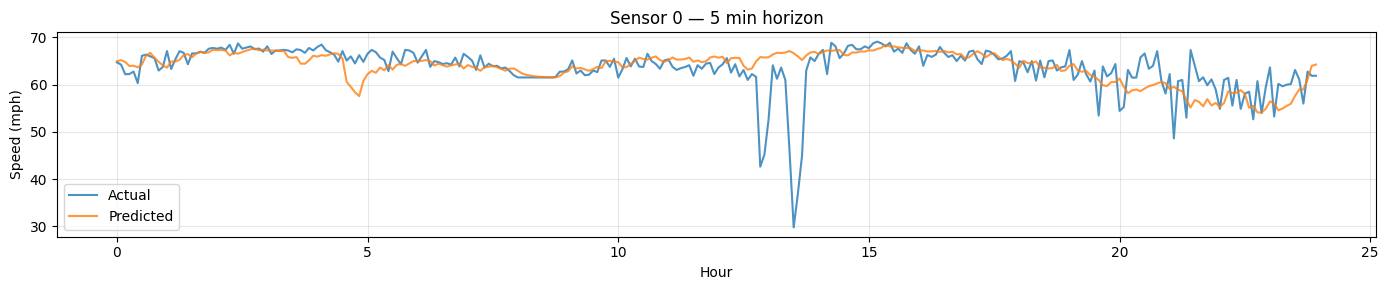

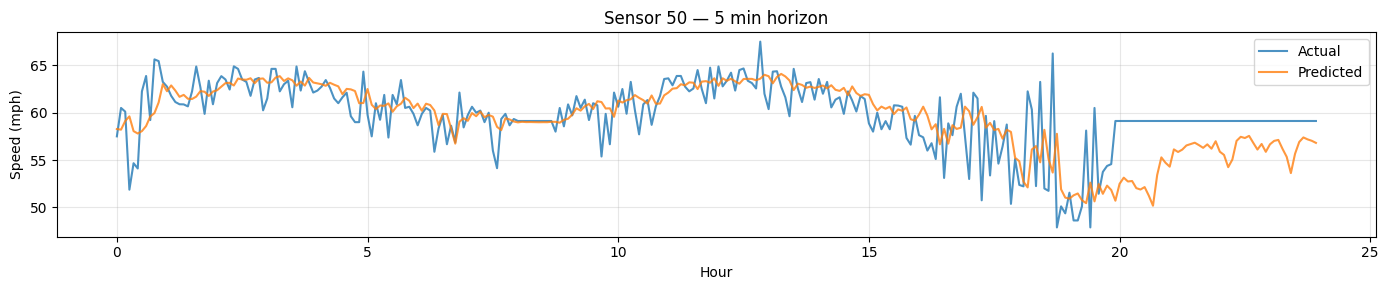

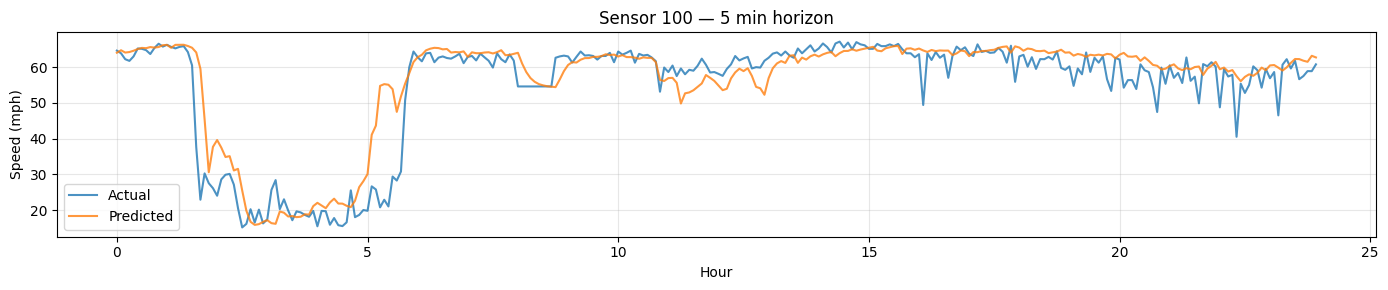

In [5]:
# Time series overlay for sample sensors
n_steps = 288  # 1 day
for sensor_idx in [0, 50, 100]:
    fig, ax = plt.subplots(figsize=(14, 3))
    x = np.arange(n_steps) * 5 / 60  # hours
    ax.plot(x, targets_orig[:n_steps, sensor_idx, 0], label='Actual', alpha=0.8)
    ax.plot(x, preds_orig[:n_steps, sensor_idx, 0], label='Predicted', alpha=0.8)
    ax.set_xlabel('Hour'); ax.set_ylabel('Speed (mph)')
    ax.set_title(f'Sensor {sensor_idx} — 5 min horizon')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

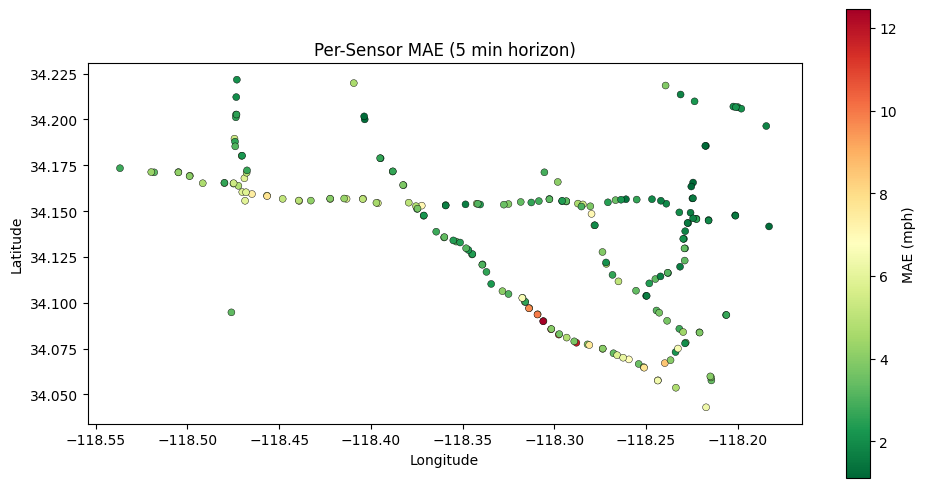

In [6]:
# Per-sensor MAE heatmap
import pandas as pd

sensor_mae = np.abs(preds_orig[:, :, 0] - targets_orig[:, :, 0]).mean(axis=0)
locs = pd.read_csv('../data/raw/graph_sensor_locations.csv')
locs = locs[['sensor_id', 'latitude', 'longitude']]

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(locs['longitude'], locs['latitude'], c=sensor_mae,
                cmap='RdYlGn_r', s=25, edgecolors='k', linewidths=0.3)
plt.colorbar(sc, ax=ax, label='MAE (mph)', shrink=0.7)
ax.ticklabel_format(useOffset=False)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Per-Sensor MAE (5 min horizon)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

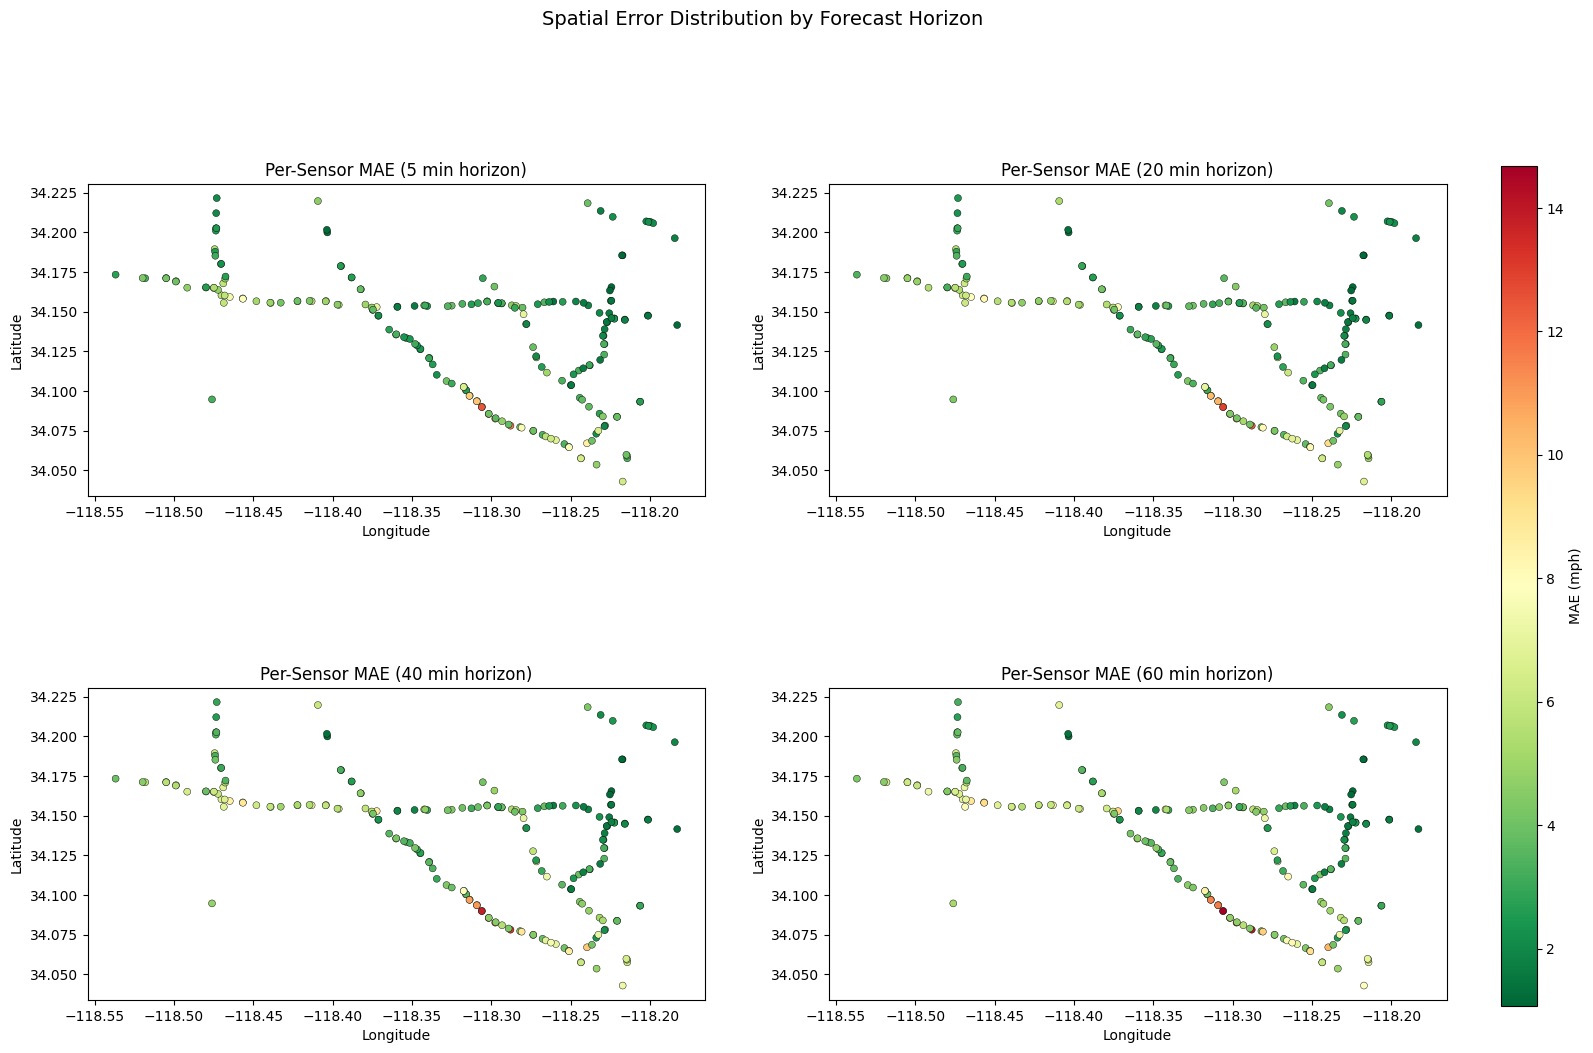

In [7]:
# Per-sensor MAE heatmaps across forecast horizons
horizons_map = {0: '5 min', 3: '20 min', 7: '40 min', 11: '60 min'}

# Compute MAE per sensor at each horizon
mae_by_horizon = {}
for h_idx, label in horizons_map.items():
    mae_by_horizon[label] = np.abs(preds_orig[:, :, h_idx] - targets_orig[:, :, h_idx]).mean(axis=0)

# Shared color scale across all panels
vmin = min(m.min() for m in mae_by_horizon.values())
vmax = max(m.max() for m in mae_by_horizon.values())

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, (label, sensor_mae) in zip(axes.flat, mae_by_horizon.items()):
    sc = ax.scatter(locs['longitude'], locs['latitude'], c=sensor_mae,
                    cmap='RdYlGn_r', s=25, edgecolors='k', linewidths=0.3,
                    vmin=vmin, vmax=vmax)
    ax.ticklabel_format(useOffset=False)
    ax.set_title(f'Per-Sensor MAE ({label} horizon)')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_aspect('equal')

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
fig.colorbar(sc, cax=cbar_ax, label='MAE (mph)')
fig.suptitle('Spatial Error Distribution by Forecast Horizon', fontsize=14)
plt.show()

## Per-Hour-of-Day Accuracy Analysis

In [8]:
# Map each test sample to its hour of day
from datetime import datetime

timestamps = np.load(f'{processed_dir}/timestamps.npy', allow_pickle=True)
T_total = len(timestamps)
val_end = int(T_total * (cfg['data']['train_ratio'] + cfg['data']['val_ratio']))

# For test sample i, first prediction target is at raw timestamp index val_end + i
hours = np.array([
    datetime.fromtimestamp(int(timestamps[val_end + i]) / 1e9).hour
    for i in range(preds_orig.shape[0])
])

print(f'Test samples: {len(hours)}')
print(f'Samples per hour:')
for h in range(24):
    count = (hours == h).sum()
    print(f'  {h:2d}:00 — {count} samples')

Test samples: 6844
Samples per hour:
   0:00 — 288 samples
   1:00 — 288 samples
   2:00 — 288 samples
   3:00 — 288 samples
   4:00 — 288 samples
   5:00 — 288 samples
   6:00 — 288 samples
   7:00 — 288 samples
   8:00 — 288 samples
   9:00 — 288 samples
  10:00 — 288 samples
  11:00 — 288 samples
  12:00 — 288 samples
  13:00 — 288 samples
  14:00 — 288 samples
  15:00 — 288 samples
  16:00 — 277 samples
  17:00 — 276 samples
  18:00 — 276 samples
  19:00 — 276 samples
  20:00 — 276 samples
  21:00 — 279 samples
  22:00 — 288 samples
  23:00 — 288 samples


In [9]:
# Per-hour metrics table
print(f'{"Hour":>4s}  {"MAE":>6s}  {"RMSE":>6s}  {"MAPE":>7s}  {"N":>5s}')
print('-' * 36)
hour_metrics = {}
for h in range(24):
    mask = hours == h
    m = compute_all_metrics(preds_orig[mask], targets_orig[mask])
    hour_metrics[h] = {**m, 'n_samples': int(mask.sum())}
    print(f'{h:4d}  {m["MAE"]:6.3f}  {m["RMSE"]:6.3f}  {m["MAPE"]:6.2f}%  {mask.sum():5d}')

Hour     MAE    RMSE     MAPE      N
------------------------------------
   0   5.965  11.556   24.90%    288
   1   5.372  10.305   21.19%    288
   2   4.422   8.704   14.98%    288
   3   3.816   7.620   11.58%    288
   4   4.167   8.231   13.12%    288
   5   4.319   8.468   14.17%    288
   6   4.768   9.052   16.40%    288
   7   5.835  10.713   22.04%    288
   8   6.906  11.475   26.05%    288
   9   6.959  11.561   27.60%    288
  10   7.084  11.795   28.65%    288
  11   6.101  10.518   21.38%    288
  12   4.111   7.733   12.29%    288
  13   2.644   5.053    6.18%    288
  14   2.535   4.820    5.61%    288
  15   2.568   5.051    6.16%    288
  16   2.690   4.794    6.00%    277
  17   2.819   4.274    5.09%    276
  18   3.054   4.423    5.43%    276
  19   3.281   4.762    5.96%    276
  20   3.324   4.767    6.04%    276
  21   2.623   3.800    4.52%    279
  22   2.664   5.679    6.37%    288
  23   4.179   8.927   14.43%    288


In [11]:
# Export full-granularity CSV for Tableau (hour x horizon x sensor)
horizons_export = {0: '5 min', 2: '15 min', 5: '30 min', 11: '60 min'}

rows = []
for h in range(24):
    mask = hours == h
    n_samples = int(mask.sum())
    p_h = preds_orig[mask]    # (n, 207, 12)
    t_h = targets_orig[mask]  # (n, 207, 12)
    for hz_idx, hz_label in horizons_export.items():
        for s in range(207):
            mae = float(np.abs(p_h[:, s, hz_idx] - t_h[:, s, hz_idx]).mean())
            rows.append({
                'hour': h,
                'horizon': hz_label,
                'sensor_idx': s,
                'sensor_id': locs.iloc[s]['sensor_id'],
                'latitude': locs.iloc[s]['latitude'],
                'longitude': locs.iloc[s]['longitude'],
                'MAE': round(mae, 4),
                'n_samples': n_samples,
            })

df_export = pd.DataFrame(rows)
Path('../results').mkdir(exist_ok=True)
df_export.to_csv('../results/hourly_sensor_metrics.csv', index=False)
print(f'Exported {len(df_export)} rows to results/hourly_sensor_metrics.csv')
print(f'\nShape: {df_export.shape}')
print(f'Columns: {list(df_export.columns)}')
print(f'\nSample rows:')
df_export.head(10)

Exported 19872 rows to results/hourly_sensor_metrics.csv

Shape: (19872, 8)
Columns: ['hour', 'horizon', 'sensor_idx', 'sensor_id', 'latitude', 'longitude', 'MAE', 'n_samples']

Sample rows:


,hour,horizon,sensor_idx,sensor_id,latitude,longitude,MAE,n_samples
0,0,5 min,0,773869.0,34.15497,-118.31829,1.0249,288
1,0,5 min,1,767541.0,34.11621,-118.23799,1.0088,288
2,0,5 min,2,767542.0,34.11641,-118.23819,17.4066,288
3,0,5 min,3,717447.0,34.07248,-118.26772,1.7170,288
4,0,5 min,4,717446.0,34.07142,-118.26572,4.4477,288
5,0,5 min,5,717445.0,34.06913,-118.25932,3.7335,288
6,0,5 min,6,773062.0,34.05368,-118.23369,3.3415,288
7,0,5 min,7,767620.0,34.13486,-118.22932,1.4452,288
8,0,5 min,8,737529.0,34.20264,-118.47352,5.7017,288
9,0,5 min,9,717816.0,34.15562,-118.46860,7.7387,288
